This gets already the shap values and goes from there

In [29]:
import pandas as pd
import pickle
import shap

In [30]:
shap_df= pd.read_csv("Shap_values/shap_values_by_gene_Catboost_40_extended.csv")
shap_df = shap_df.loc[:, (shap_df != 0).any(axis=0)]
shap_df


,CFTR,RECQL,HSPB6,SKAP2,GGCT,BLTP2,FAM76A,TFB1M,DAPK2,ZZZ3,...,ENSG00000271250.1,ENSG00000271900.1,ENSG00000272346.2,ENSG00000274691.1,ENSG00000277998.1,ENSG00000278687.1,RNA5SP196,ENSG00000281228.1,ENSG00000281269.1,ENSG00000285043.1
0,-0.005113,-0.005353,-0.325891,0.000460,0.008998,-0.000666,0.002350,0.000852,-0.090946,-0.001210,...,-0.029375,-0.007741,-0.000340,-0.029314,-0.014582,-0.018644,-0.003715,0.002263,-0.006067,-0.956877
1,0.002895,-0.005353,-0.303287,0.000460,0.007890,-0.000666,-0.007234,0.000290,-0.090946,-0.001210,...,-0.029375,-0.004148,-0.000340,-0.029314,0.011146,-0.018644,-0.003715,0.001147,-0.006067,-0.923986
2,0.002895,-0.005353,-0.308063,0.000460,0.008531,-0.000666,0.005304,0.000290,-0.090946,-0.001210,...,-0.029375,-0.004148,-0.000340,-0.029314,0.011146,-0.018644,-0.003715,0.001035,-0.006067,-0.956877
3,-0.009493,0.000080,-0.343898,0.000460,0.015917,0.002046,-0.019778,0.000290,-0.090946,0.002180,...,-0.026113,0.001176,-0.000026,-0.030390,0.014695,-0.018644,0.003442,0.001895,-0.006067,-1.231752
4,0.005375,0.007549,0.161753,0.001225,0.036960,-0.014282,0.009212,-0.032461,0.105844,-0.033543,...,-0.026113,0.006943,0.000372,-0.020013,-0.001981,0.017001,0.003442,0.003122,0.005479,0.765995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,-0.009493,0.007549,0.160536,0.001225,0.036658,0.006760,0.012837,0.005087,0.105844,0.002180,...,-0.026113,0.006943,0.000372,-0.029296,-0.001981,0.017001,0.003442,0.003122,0.005479,0.765995
104,0.002895,0.374724,-0.313143,0.000460,0.008763,-0.000666,-0.010093,0.000290,-0.090946,-0.001210,...,-0.029375,-0.007741,-0.000340,-0.029314,0.011146,-0.018644,-0.003715,0.001035,-0.006067,-0.867345
105,-0.009493,0.006481,0.166264,0.000587,0.039320,0.006760,0.012837,0.005087,0.105844,0.002180,...,-0.026113,0.006943,0.000372,0.017593,0.014695,0.017001,0.003442,0.003122,0.005479,0.850476
106,-0.009493,0.008056,0.157861,0.001225,0.041321,0.002046,-0.019778,0.005087,0.105844,-0.033543,...,0.029290,0.006943,0.000372,-0.029296,-0.019321,0.017001,0.003442,0.003122,0.005479,0.818875


In [44]:
shap_average = pd.read_csv("Shap_values/average_shap_value_by_gene_Catboost_40_extended_2.csv")
shap_average


,Gene,Average
0,NT5C2,0.369183
1,ENSG00000262855.1,0.363098
2,SLC16A3,0.287879
3,BLCAP,0.283239
4,MTFR1,0.249598
...,...,...
350,HSPH1,-0.028376
351,PAN2,-0.047177
352,RNA5SP460,-0.049432
353,UBE2H,-0.057687


In [31]:
top_genes={}
for index, row in shap_df.iterrows():
    top_50_genes = row.abs().nlargest(10)
    # save the origial shapvalue non abs
    genes = top_50_genes.index
    origial_shapvalue = row[genes]
    top_genes[index] = origial_shapvalue.to_dict()

In [32]:
with open('Shap_values/shap_values_catboost.pkl', 'rb') as f:
    shap_values = pickle.load(f)


In [33]:
test_file="Shap_values/RNAseq_Combat_z_score_Test_set.csv"
test_data = pd.read_csv(test_file)
test_data = test_data.fillna(0)
test_data.drop(columns=["Age.1"], inplace=True)
X_test_data = test_data[test_data.columns[:-5]]
z_test_data = test_data[test_data.columns[-4:]]
y_test_data = test_data["Age"]
z_test_data = z_test_data["Experiment"]

In [34]:
results = pd.read_csv("Shap_values/results_validationSet_actualVspredicted_catboost.csv")

Sample 0/ 108 
 Age: 24.0 
 Experiment: GSE157585 
 Predicted: Unnamed: 0            0
Actual             24.0
Predicted     23.221191
Group         GSE157585
Name: 0, dtype: object


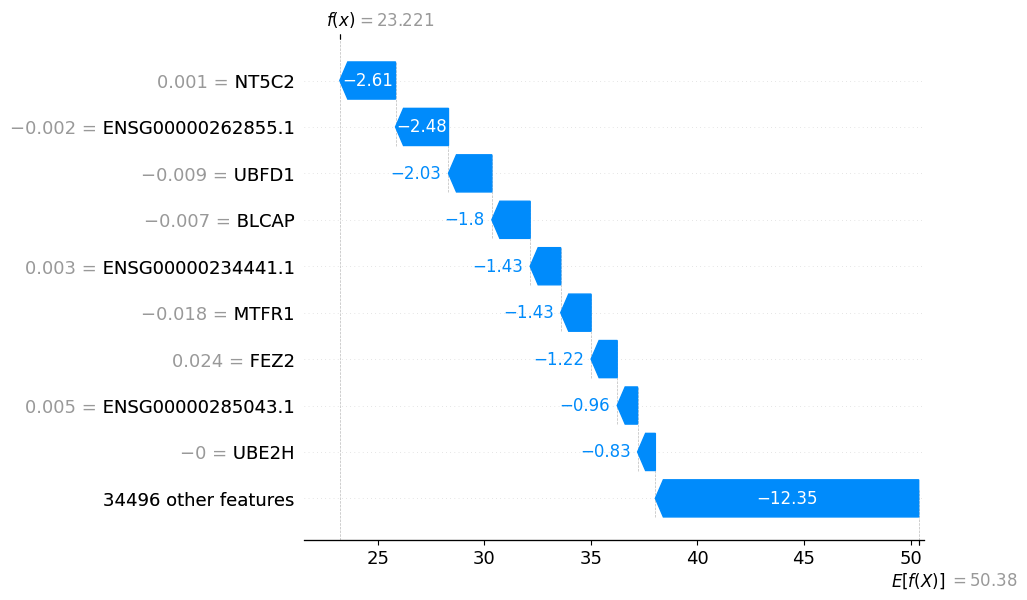

In [35]:
index=0
title = f"Sample {index}/ {len(shap_values)} \n Age: {y_test_data[index]} \n Experiment: {z_test_data[index]} \n Predicted: {results.iloc[index]}"

print(title)
shap.plots.waterfall(shap_values[index])

In [36]:
top_genes[index]

{'NT5C2': -2.614314641746164,
 'ENSG00000262855.1': -2.4848006030321184,
 'UBFD1': -2.0349535396100915,
 'BLCAP': -1.797882117900783,
 'ENSG00000234441.1': -1.432804643607754,
 'MTFR1': -1.4255599349700894,
 'FEZ2': -1.224162504512254,
 'ENSG00000285043.1': -0.9568771074869746,
 'UBE2H': -0.8336168940812262,
 'RNA5SP460': -0.779692837794504}

108